## Data Preprocessing

In [1]:
import pandas as pd

In [2]:
dataframe = pd.read_csv('watson_healthcare_modified.csv')
dataframe.sample(4)

,EmployeeID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
313,1172739,33,No,Travel_Frequently,553,Neurology,5,4,Life Sciences,1,...,2,80,2,12,2,3,10,6,8,8
1318,1402268,47,No,Travel_Rarely,207,Neurology,9,4,Life Sciences,1,...,3,80,0,7,2,3,2,2,2,0
286,1353021,44,Yes,Travel_Frequently,920,Maternity,24,3,Life Sciences,1,...,4,80,1,19,0,1,1,0,0,0
1013,1611839,31,Yes,Travel_Rarely,202,Maternity,8,3,Life Sciences,1,...,3,80,0,1,3,4,1,0,0,0


In [3]:
dataframe.shape

(1676, 35)

In [4]:
dataframe.select_dtypes(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,No,Travel_Rarely,Cardiology,Life Sciences,Female,Nurse,Single,Y,Yes
1,No,Travel_Frequently,Maternity,Life Sciences,Male,Other,Married,Y,No
2,Yes,Travel_Rarely,Maternity,Other,Male,Nurse,Single,Y,Yes
3,No,Travel_Frequently,Maternity,Life Sciences,Female,Other,Married,Y,Yes
4,No,Travel_Rarely,Maternity,Medical,Male,Nurse,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1671,Yes,Travel_Rarely,Neurology,Technical Degree,Male,Nurse,Single,Y,Yes
1672,No,Travel_Rarely,Cardiology,Marketing,Female,Nurse,Married,Y,Yes
1673,No,Travel_Rarely,Maternity,Life Sciences,Female,Other,Single,Y,No
1674,No,Travel_Rarely,Neurology,Life Sciences,Female,Therapist,Married,Y,No


In [5]:
dframe = dataframe.copy()
dframe.tail(5)
del dataframe # For original dataset safety

### Train/Test Splitting

In [6]:
y = dframe['Attrition']
X = dframe.drop('Attrition', axis=1)

In [7]:
(dframe.dtypes).unique()
del dframe # Save memory

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)

(1340, 34)

(336, 34)

(1340,)

(336,)

Encoding only the train sets to prevent data leakage

#### Attrition Mapping 

In [11]:
# mapping attrition columns to 1s and 0s
y_test = y_test.map({'Yes': 1, 'No': 0})
y_train = y_train.map({'Yes': 1, 'No': 0})
display(y_test.head(7))
display(y_train.tail(7))

1260    0
709     1
261     0
107     1
1639    0
228     0
1226    0
Name: Attrition, dtype: int64

382     0
428     0
735     0
1350    1
71      0
320     0
552     0
Name: Attrition, dtype: int64

#### Test set unwanted feature deletion

In [12]:
EmployeeID_safe = X_test['EmployeeID']
dropping_columns = ['EmployeeID', 'Over18', 'EmployeeCount', 'StandardHours']
X_test.drop(dropping_columns, axis=1, inplace=True)
X_test.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1260,42,Travel_Rarely,855,Maternity,12,3,Medical,2,Male,57,...,4,2,3,7,6,2,5,3,0,4
709,29,Travel_Rarely,906,Maternity,10,3,Life Sciences,4,Female,92,...,4,3,0,3,5,3,0,0,0,0
261,38,Non-Travel,1327,Cardiology,2,2,Life Sciences,4,Male,39,...,3,4,1,13,0,3,8,7,7,5
107,25,Travel_Rarely,240,Cardiology,5,3,Marketing,3,Male,46,...,3,4,0,6,1,3,6,4,0,3
1639,29,Travel_Rarely,352,Neurology,6,1,Medical,4,Male,87,...,3,4,0,1,3,3,1,0,0,0


#### Train set unwanted feature deletion

In [13]:
X_train.drop(dropping_columns, axis=1, inplace=True)
X_train.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
417,40,Travel_Rarely,1398,Cardiology,2,4,Life Sciences,3,Female,79,...,3,4,0,21,2,3,20,15,1,12
243,40,Travel_Rarely,1300,Maternity,24,2,Technical Degree,1,Male,62,...,3,1,2,9,3,3,9,8,4,7
1628,25,Travel_Rarely,622,Cardiology,13,1,Medical,2,Male,40,...,3,3,0,7,1,3,7,4,0,6
454,33,Travel_Rarely,922,Maternity,1,5,Medical,1,Female,95,...,3,3,1,10,2,3,6,1,0,5
1532,39,Travel_Frequently,505,Maternity,2,4,Technical Degree,3,Female,64,...,4,4,0,20,1,3,19,6,11,8


In [14]:
X_train.select_dtypes(include='int64')

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
417,40,1398,2,4,3,79,3,5,3,18041,...,3,4,0,21,2,3,20,15,1,12
243,40,1300,24,2,1,62,3,2,4,3319,...,3,1,2,9,3,3,9,8,4,7
1628,25,622,13,1,2,40,3,1,3,2096,...,3,3,0,7,1,3,7,4,0,6
454,33,922,1,5,1,95,4,4,3,16184,...,3,3,1,10,2,3,6,1,0,5
1532,39,505,2,4,3,64,3,3,3,10938,...,4,4,0,20,1,3,19,6,11,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,41,549,7,2,4,42,3,2,3,5003,...,3,2,0,8,6,3,2,2,2,1
1350,56,1162,24,2,1,97,3,1,4,2587,...,3,4,0,5,3,3,4,2,1,0
71,29,1328,2,3,3,76,3,1,2,2703,...,4,4,1,6,3,3,5,4,0,4
320,27,1377,2,3,4,74,3,2,3,4478,...,3,1,0,5,3,3,5,4,0,4


In [15]:
X_train.select_dtypes(include='object')

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
417,Travel_Rarely,Cardiology,Life Sciences,Female,Administrative,Married,No
243,Travel_Rarely,Maternity,Technical Degree,Male,Other,Divorced,No
1628,Travel_Rarely,Cardiology,Medical,Male,Other,Married,No
454,Travel_Rarely,Maternity,Medical,Female,Administrative,Divorced,No
1532,Travel_Frequently,Maternity,Technical Degree,Female,Other,Single,No
...,...,...,...,...,...,...,...
735,Travel_Rarely,Cardiology,Medical,Female,Therapist,Single,No
1350,Travel_Rarely,Neurology,Life Sciences,Male,Nurse,Single,No
71,Travel_Rarely,Maternity,Life Sciences,Male,Other,Married,No
320,Travel_Rarely,Cardiology,Life Sciences,Male,Nurse,Single,Yes


### Encoding Objects to Numerical Values

In [16]:
from sklearn.preprocessing import OneHotEncoder

In [17]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='error').set_output(transform='pandas')

#### Gender and Department encoding (ohe) and merging

In [18]:
enc_gender = ohe.fit_transform(X_train[['Gender']])
trans_gender = ohe.transform(X_test[['Gender']])
enc_department = ohe.fit_transform(X_train[['Department']])
trans_department = ohe.transform(X_test[['Department']])

In [19]:
display(enc_gender.sample(5))
display(trans_gender.sample(5))

,Gender_Female,Gender_Male
1052,0.0,1.0
544,0.0,1.0
1662,1.0,0.0
1304,1.0,0.0
1143,0.0,1.0


,Gender_Female,Gender_Male
956,0.0,1.0
54,1.0,0.0
163,0.0,1.0
944,0.0,1.0
333,1.0,0.0


In [20]:
display(enc_department.sample(4))
display(trans_department.sample(4))

,Department_Cardiology,Department_Maternity,Department_Neurology
365,0.0,0.0,1.0
500,1.0,0.0,0.0
178,1.0,0.0,0.0
835,1.0,0.0,0.0


,Department_Cardiology,Department_Maternity,Department_Neurology
43,1.0,0.0,0.0
1609,0.0,0.0,1.0
1005,0.0,1.0,0.0
1471,0.0,1.0,0.0


In [21]:
X_train = pd.concat([X_train, enc_department], axis=1).drop(columns=['Department'])
X_test = pd.concat([X_test, trans_department], axis=1).drop(columns=['Department'])
print(f'Test Set: {X_test.shape}')
display(X_test.sample(5))
print(f'Train Set: {X_train.shape}')
display(X_train.sample(5))

Test Set: (336, 32)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology
301,18,Travel_Rarely,812,10,3,Medical,4,Female,69,2,...,0,2,3,0,0,0,0,1.0,0.0,0.0
986,37,Travel_Rarely,1439,4,1,Life Sciences,3,Male,54,3,...,8,2,3,6,4,1,3,0.0,1.0,0.0
1529,22,Travel_Rarely,581,1,2,Life Sciences,4,Male,63,3,...,4,2,4,3,2,1,2,0.0,1.0,0.0
1570,31,Travel_Rarely,1332,11,2,Medical,3,Male,80,3,...,6,2,2,6,5,0,1,0.0,1.0,0.0
307,38,Travel_Rarely,849,25,2,Life Sciences,1,Female,81,2,...,19,2,3,10,8,0,1,0.0,1.0,0.0


Train Set: (1340, 32)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology
960,38,Travel_Rarely,1009,2,2,Life Sciences,2,Female,31,3,...,11,3,3,7,7,1,7,1.0,0.0,0.0
763,50,Travel_Rarely,1464,2,4,Medical,2,Male,62,3,...,29,2,2,8,1,7,7,0.0,1.0,0.0
870,36,Travel_Rarely,917,6,4,Life Sciences,3,Male,60,1,...,7,4,3,7,7,1,7,0.0,1.0,0.0
1258,38,Travel_Rarely,833,18,3,Medical,2,Male,60,1,...,15,2,3,1,0,1,0,0.0,1.0,0.0
468,32,Non-Travel,1474,11,4,Other,4,Male,60,4,...,6,2,3,4,2,1,2,1.0,0.0,0.0


In [22]:
X_train = pd.concat([X_train, enc_gender], axis=1).drop(columns=['Gender'])
X_test = pd.concat([X_test, trans_gender], axis=1).drop(columns=['Gender'])
print(f'Test Set: {X_test.shape}')
display(X_test.sample(5))
print(f'Train Set: {X_train.shape}')
display(X_train.sample(5))

Test Set: (336, 33)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
783,27,Non-Travel,1277,8,5,Life Sciences,1,87,1,1,...,3,3,2,1,2,0.0,1.0,0.0,0.0,1.0
1065,28,Travel_Frequently,289,2,2,Medical,3,38,2,1,...,2,0,0,0,0,0.0,1.0,0.0,0.0,1.0
248,37,Travel_Rarely,1017,1,2,Medical,3,83,2,1,...,2,3,1,0,2,0.0,1.0,0.0,1.0,0.0
1500,41,Travel_Rarely,645,1,3,Marketing,2,49,4,3,...,3,10,7,0,7,1.0,0.0,0.0,0.0,1.0
794,26,Travel_Rarely,1330,21,3,Medical,1,37,3,1,...,2,1,1,0,0,0.0,1.0,0.0,0.0,1.0


Train Set: (1340, 33)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
652,39,Travel_Rarely,1383,2,3,Life Sciences,4,42,2,2,...,3,5,4,0,4,0.0,0.0,1.0,1.0,0.0
898,48,Travel_Rarely,969,2,2,Technical Degree,4,76,4,1,...,2,1,0,0,0,0.0,1.0,0.0,0.0,1.0
569,26,Travel_Frequently,575,1,2,Life Sciences,1,71,1,1,...,3,2,2,2,0,0.0,1.0,0.0,1.0,0.0
975,40,Travel_Rarely,1202,2,1,Medical,2,89,4,2,...,3,12,11,11,8,0.0,1.0,0.0,1.0,0.0
1318,47,Travel_Rarely,207,9,4,Life Sciences,2,64,3,1,...,3,2,2,2,0,0.0,0.0,1.0,1.0,0.0


#### OverTime encoding (mapping to 1s and 0s)

In [23]:
X_train['OverTime']

417      No
243      No
1628     No
454      No
1532     No
       ... 
735      No
1350     No
71       No
320     Yes
552      No
Name: OverTime, Length: 1340, dtype: object

In [24]:
# yes = 1 | no = 0  
X_train['OverTime'] = X_train['OverTime'].map({'Yes': 1, 'No': 0})
X_test['OverTime'] = X_test['OverTime'].map({'Yes': 1, 'No': 0})

In [25]:
display(X_train.head(7))
display(X_test.head(7))

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
417,40,Travel_Rarely,1398,2,4,Life Sciences,3,79,3,5,...,3,20,15,1,12,1.0,0.0,0.0,1.0,0.0
243,40,Travel_Rarely,1300,24,2,Technical Degree,1,62,3,2,...,3,9,8,4,7,0.0,1.0,0.0,0.0,1.0
1628,25,Travel_Rarely,622,13,1,Medical,2,40,3,1,...,3,7,4,0,6,1.0,0.0,0.0,0.0,1.0
454,33,Travel_Rarely,922,1,5,Medical,1,95,4,4,...,3,6,1,0,5,0.0,1.0,0.0,1.0,0.0
1532,39,Travel_Frequently,505,2,4,Technical Degree,3,64,3,3,...,3,19,6,11,8,0.0,1.0,0.0,1.0,0.0
331,27,Non-Travel,210,1,1,Marketing,3,73,3,2,...,3,5,4,1,4,1.0,0.0,0.0,0.0,1.0
1110,32,Non-Travel,1200,1,4,Technical Degree,4,62,3,2,...,2,6,5,1,2,0.0,1.0,0.0,0.0,1.0


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
1260,42,Travel_Rarely,855,12,3,Medical,2,57,3,1,...,2,5,3,0,4,0.0,1.0,0.0,0.0,1.0
709,29,Travel_Rarely,906,10,3,Life Sciences,4,92,2,1,...,3,0,0,0,0,0.0,1.0,0.0,1.0,0.0
261,38,Non-Travel,1327,2,2,Life Sciences,4,39,2,2,...,3,8,7,7,5,1.0,0.0,0.0,0.0,1.0
107,25,Travel_Rarely,240,5,3,Marketing,3,46,2,2,...,3,6,4,0,3,1.0,0.0,0.0,0.0,1.0
1639,29,Travel_Rarely,352,6,1,Medical,4,87,2,1,...,3,1,0,0,0,0.0,0.0,1.0,0.0,1.0
228,35,Travel_Frequently,944,1,3,Marketing,3,92,3,3,...,4,10,7,0,8,1.0,0.0,0.0,1.0,0.0
1226,40,Travel_Rarely,369,8,2,Life Sciences,2,92,3,2,...,3,1,0,0,0,0.0,1.0,0.0,1.0,0.0


#### Ordinal encoding for BusinessTravel and MaritalStatus

In [26]:
travel_frequency = ['Non-Travel', 'Travel_Rarely', 'Travel_Frequently'] # 0.0 = Non-Travel, 1.0 = Travel_Rarely, 2.0 = Travel_Frequently
marital_status = ['Single','Married', 'Divorced'] # 0.0 = Single, 1.0 = Married, 2.0 = Divorced

In [27]:
from sklearn.preprocessing import OrdinalEncoder

In [28]:
oe_travel = OrdinalEncoder(categories=[travel_frequency])
oe_marital_status = OrdinalEncoder(categories= [marital_status])

In [29]:
X_train['BusinessTravel'] = oe_travel.fit_transform(X_train[['BusinessTravel']])
X_test['BusinessTravel'] = oe_travel.transform(X_test[['BusinessTravel']])

In [30]:
X_train['MaritalStatus'] = oe_marital_status.fit_transform(X_train[['MaritalStatus']])
X_test['MaritalStatus'] = oe_marital_status.transform(X_test[['MaritalStatus']])

In [31]:
display((X_train[['BusinessTravel','MaritalStatus']]).sample(7))
display((X_test[['BusinessTravel','MaritalStatus']]).sample(7))

,BusinessTravel,MaritalStatus
236,1.0,1.0
865,1.0,1.0
726,1.0,1.0
1211,1.0,1.0
1025,1.0,1.0
1140,0.0,1.0
924,1.0,0.0


,BusinessTravel,MaritalStatus
515,1.0,1.0
280,1.0,1.0
881,1.0,2.0
16,1.0,2.0
1540,0.0,1.0
460,1.0,0.0
532,1.0,1.0


In [32]:
max_len = max(len(col) for col in X_train.columns) # finds the length of the largest column name

for col in X_train.columns:
    print(f'{col:<{max_len}} = {X_train[col].nunique()}') # left aligns the column name

Age                      = 43
BusinessTravel           = 3
DailyRate                = 793
DistanceFromHome         = 29
Education                = 5
EducationField           = 6
EnvironmentSatisfaction  = 4
HourlyRate               = 71
JobInvolvement           = 4
JobLevel                 = 5
JobRole                  = 5
JobSatisfaction          = 4
MaritalStatus            = 3
MonthlyIncome            = 1134
MonthlyRate              = 1191
NumCompaniesWorked       = 10
OverTime                 = 2
PercentSalaryHike        = 15
PerformanceRating        = 2
RelationshipSatisfaction = 4
Shift                    = 4
TotalWorkingYears        = 40
TrainingTimesLastYear    = 7
WorkLifeBalance          = 4
YearsAtCompany           = 37
YearsInCurrentRole       = 19
YearsSinceLastPromotion  = 16
YearsWithCurrManager     = 18
Department_Cardiology    = 2
Department_Maternity     = 2
Department_Neurology     = 2
Gender_Female            = 2
Gender_Male              = 2


In [33]:
display((X_train['JobRole'] == 'Other').sum())
display((X_test['JobRole'] == 'Other').sum())

np.int64(434)

np.int64(100)

In [34]:
display((X_train['EducationField'] == 'Other').sum())
display((X_test['EducationField'] == 'Other').sum())

np.int64(75)

np.int64(13)

In [35]:
display((X_train['OverTime'] == 1).sum())
display((X_test['OverTime'] == 1).sum())

np.int64(386)

np.int64(90)

In [36]:
display((y_train == 1).sum())
display((y_test == 1).sum())

np.int64(159)

np.int64(40)

In [37]:
X_train.sample(7)

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
87,51,1.0,432,9,4,Life Sciences,4,96,3,1,...,3,4,2,0,3,0.0,1.0,0.0,0.0,1.0
1130,43,1.0,990,27,3,Technical Degree,4,87,4,1,...,3,6,4,0,2,0.0,1.0,0.0,0.0,1.0
1061,30,1.0,330,1,3,Life Sciences,3,46,3,1,...,4,5,3,1,3,0.0,0.0,1.0,0.0,1.0
964,40,1.0,329,1,4,Life Sciences,2,88,3,1,...,3,4,2,0,3,0.0,1.0,0.0,0.0,1.0
5,32,2.0,1005,2,2,Life Sciences,4,79,3,1,...,2,7,7,3,6,0.0,1.0,0.0,0.0,1.0
1603,45,1.0,930,9,3,Marketing,4,74,3,3,...,3,5,4,0,2,1.0,0.0,0.0,0.0,1.0
291,36,1.0,506,3,3,Technical Degree,3,30,3,2,...,3,8,0,7,7,0.0,1.0,0.0,0.0,1.0


In [38]:
X_test.sample(7)

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
961,34,1.0,507,15,2,Medical,3,66,3,2,...,4,10,8,9,6,1.0,0.0,0.0,1.0,0.0
275,37,0.0,728,1,4,Medical,1,80,3,3,...,3,5,2,0,2,0.0,0.0,1.0,1.0,0.0
173,30,0.0,111,9,3,Medical,3,66,3,2,...,3,12,9,6,10,0.0,1.0,0.0,0.0,1.0
393,34,0.0,1381,4,4,Marketing,3,72,3,2,...,3,3,2,1,2,1.0,0.0,0.0,1.0,0.0
1,49,2.0,279,8,1,Life Sciences,3,61,2,2,...,3,10,7,1,7,0.0,1.0,0.0,0.0,1.0
150,40,2.0,1395,26,3,Medical,2,54,3,2,...,3,20,7,2,13,0.0,1.0,0.0,1.0,0.0
497,33,1.0,1216,8,4,Marketing,3,39,3,2,...,3,5,0,1,2,1.0,0.0,0.0,0.0,1.0


#### JobRole and EducationField encoding (categorical mapping)

In [39]:
X_train['EducationField'] = X_train['EducationField'].map({'Other': 0, 'Life Sciences': 1, 'Medical': 2, 'Marketing': 3, 'Technical Degree': 4, 'Human Resources': 5})
X_train['is_other_JobRole'] = (X_train['JobRole'] == 'Other').astype(int)
X_train['JobRole'] = X_train['JobRole'].map({'Other': 0, 'Nurse': 1,'Therapist': 2, 'Administrative': 3, 'Admin': 4})

In [40]:
(X_train[['EducationField','is_other_JobRole','JobRole']]).sample(5)

,EducationField,is_other_JobRole,JobRole
433,1,0,2
793,4,0,1
622,3,0,1
1127,1,0,1
158,3,0,1


In [41]:
X_test['EducationField'] = X_test['EducationField'].map({'Other': 0, 'Life Sciences': 1, 'Medical': 2, 'Marketing': 3, 'Technical Degree': 4, 'Human Resources': 5})
X_test['is_other_JobRole'] = (X_test['JobRole'] == 'Other').astype(int)
X_test['JobRole'] = X_test['JobRole'].map({'Other': 0, 'Nurse': 1,'Therapist': 2, 'Administrative': 3, 'Admin': 4})

In [42]:
(X_test[['EducationField','is_other_JobRole','JobRole']]).sample(5)

,EducationField,is_other_JobRole,JobRole
1574,2,0,1
739,1,0,1
1565,3,0,2
1586,1,0,1
1386,4,0,1


In [43]:
X_train.dtypes

Age                           int64
BusinessTravel              float64
DailyRate                     int64
DistanceFromHome              int64
Education                     int64
EducationField                int64
EnvironmentSatisfaction       int64
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                       int64
JobSatisfaction               int64
MaritalStatus               float64
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
OverTime                      int64
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
Shift                         int64
TotalWorkingYears             int64
TrainingTimesLastYear         int64
WorkLifeBalance               int64
YearsAtCompany                int64
YearsInCurrentRole            int64
YearsSinceLastPromotion       int64
YearsWithCurrManager        

In [44]:
X_test.dtypes

Age                           int64
BusinessTravel              float64
DailyRate                     int64
DistanceFromHome              int64
Education                     int64
EducationField                int64
EnvironmentSatisfaction       int64
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                       int64
JobSatisfaction               int64
MaritalStatus               float64
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
OverTime                      int64
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
Shift                         int64
TotalWorkingYears             int64
TrainingTimesLastYear         int64
WorkLifeBalance               int64
YearsAtCompany                int64
YearsInCurrentRole            int64
YearsSinceLastPromotion       int64
YearsWithCurrManager        

In [45]:
# checking all the dtypes are equal in  train and test sets
display((X_train.dtypes == X_test.dtypes).any() )
display(y_train.dtype == y_test.dtype)

np.True_

True

In [46]:
display(X_train.shape)
display(X_test.shape)

(1340, 34)

(336, 34)

In [47]:
X_train.isna().any().any()

np.False_

In [48]:
X_test.isna().any().any()

np.False_

In [49]:
X_test.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education',
       'EducationField', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'Shift', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'Department_Cardiology', 'Department_Maternity', 'Department_Neurology',
       'Gender_Female', 'Gender_Male', 'is_other_JobRole'],
      dtype='object')

In [50]:
X_test.shape

(336, 34)

### Combining Train Cases to train_set and Test Cases to test_set

In [51]:
train_set = pd.concat([X_train, y_train], axis=1)
display(train_set.shape)
train_set.head()

(1340, 35)

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male,is_other_JobRole,Attrition
417,40,1.0,1398,2,4,1,3,79,3,5,...,15,1,12,1.0,0.0,0.0,1.0,0.0,0,0
243,40,1.0,1300,24,2,4,1,62,3,2,...,8,4,7,0.0,1.0,0.0,0.0,1.0,1,0
1628,25,1.0,622,13,1,2,2,40,3,1,...,4,0,6,1.0,0.0,0.0,0.0,1.0,1,0
454,33,1.0,922,1,5,2,1,95,4,4,...,1,0,5,0.0,1.0,0.0,1.0,0.0,0,0
1532,39,2.0,505,2,4,4,3,64,3,3,...,6,11,8,0.0,1.0,0.0,1.0,0.0,1,0


In [52]:
test_set = pd.concat([X_test, y_test], axis=1)
display(test_set.shape)
test_set.head()

(336, 35)

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male,is_other_JobRole,Attrition
1260,42,1.0,855,12,3,2,2,57,3,1,...,3,0,4,0.0,1.0,0.0,0.0,1.0,0,0
709,29,1.0,906,10,3,1,4,92,2,1,...,0,0,0,0.0,1.0,0.0,1.0,0.0,1,1
261,38,0.0,1327,2,2,1,4,39,2,2,...,7,7,5,1.0,0.0,0.0,0.0,1.0,0,0
107,25,1.0,240,5,3,3,3,46,2,2,...,4,0,3,1.0,0.0,0.0,0.0,1.0,0,1
1639,29,1.0,352,6,1,2,4,87,2,1,...,0,0,0,0.0,0.0,1.0,0.0,1.0,1,0


In [53]:
train_set.to_csv('train_set_datasheet.csv', index=False)
test_set.to_csv('test_set_datasheet.csv', index=False)

In [54]:
full_prepared_dataset = pd.concat([train_set, test_set], axis=1)
display(full_prepared_dataset.shape)
full_prepared_dataset.head()

(1676, 70)

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male,is_other_JobRole,Attrition
417,40.0,1.0,1398.0,2.0,4.0,1.0,3.0,79.0,3.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243,40.0,1.0,1300.0,24.0,2.0,4.0,1.0,62.0,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1628,25.0,1.0,622.0,13.0,1.0,2.0,2.0,40.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
454,33.0,1.0,922.0,1.0,5.0,2.0,1.0,95.0,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1532,39.0,2.0,505.0,2.0,4.0,4.0,3.0,64.0,3.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cross Validation

In [55]:
import warnings
warnings.filterwarnings('ignore')

In [56]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

In [57]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv2 = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
cv3 = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)

In [58]:
from sklearn.metrics import RocCurveDisplay, auc, roc_curve

In [59]:
cvs = [cv, cv2, cv3]

In [60]:
def plot_custom_roc_cv(estimator, X, y, cv_i, title="ROC Curve"):

    n_splits=(5 + ((cvs.index(i) + 1) - 1)*2)
    
    cv = StratifiedKFold(n_splits=n_splits)
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    fig, ax = plt.subplots(figsize=(8, 6))

    for fold, (train, test) in enumerate(cv.split(X, y)):
        estimator.fit(X.iloc[train], y.iloc[train])
        viz = RocCurveDisplay.from_estimator(
            estimator,
            X.iloc[test],
            y.iloc[test],
            name=f"ROC fold {fold}",
            alpha=0.3,
            lw=1,
            ax=ax,
        )
        interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(viz.roc_auc)

    ax.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    
    ax.plot(
        mean_fpr,
        mean_tpr,
        color="b",
        label=f"Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})",
        lw=2,
        alpha=0.8,
    )

    ax.set(
        xlim=[-0.05, 1.05],
        ylim=[-0.05, 1.05],
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=title,
    )
    ax.legend(loc="lower right")
    plt.show()
    
    return mean_auc

In [61]:
from sklearn.metrics import precision_score, recall_score

In [63]:
def proba_divider_threshold(y_test, y_test_proba):
    decimal_prob_range = np.arange(0.25, 0.76, 0.01)
    
    threshold_precision = {}
    threshold_recall = {}
    
    for i in decimal_prob_range:
        i = round(i, 2)
        y_pred_binary = (y_test_proba >= i).astype(int)
        
        precision_1 = precision_score(y_test, y_pred_binary, pos_label=1, zero_division=0)
        recall_1    = recall_score(y_test, y_pred_binary, pos_label=1, zero_division=0)
    
        threshold_precision[i] = precision_1
        threshold_recall[i] = recall_1
    
    max_precision_proba = max(threshold_precision, key=threshold_precision.get)
    max_recall_proba = max(threshold_recall, key=threshold_recall.get)
    
    print(f'Probability With Max Precision: {max_precision_proba}')
    print(f'Probability With Max Recall: {max_recall_proba}')

    return max_precision_proba, max_recall_proba

### CV with Logistic Regression Model

In [64]:
from sklearn.linear_model import LogisticRegression

In [65]:
lr_score_list = []
for i in cvs:
    lr = LogisticRegression(max_iter=500, random_state=42)
    
    lr_scores = cross_val_score(
        lr,
        X_train,
        y_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'LR CV ROC-AUC: {lr_scores}')
    print(f'Mean ROC-AUC : {lr_scores.mean()}\n\nRounded ROC-AUC: {round(lr_scores.mean(), 3)}')
    lr_score_list.append(lr_scores.mean())
    print()
    
max_lr_score = max(lr_score_list)
print(f'>>> Max lr_score = {round(max_lr_score, 3)}')

---- 5 cv n_splits----

LR CV ROC-AUC: [0.88335375 0.87182203 0.89141949 0.82719809 0.89764301]
Mean ROC-AUC : 0.8742872753897014

Rounded ROC-AUC: 0.874

---- 7 cv n_splits----

LR CV ROC-AUC: [0.88577309 0.85721636 0.90069462 0.84588488 0.86148467 0.82220497
 0.84756729]
Mean ROC-AUC : 0.8601179836249117

Rounded ROC-AUC: 0.86

---- 9 cv n_splits----

LR CV ROC-AUC: [0.89171123 0.88680927 0.84308736 0.91263783 0.85538592 0.8562341
 0.85793045 0.85793045 0.89896722]
Mean ROC-AUC : 0.87341042516166

Rounded ROC-AUC: 0.873

>>> Max lr_score = 0.874



Generating plots for 5 n_splits...



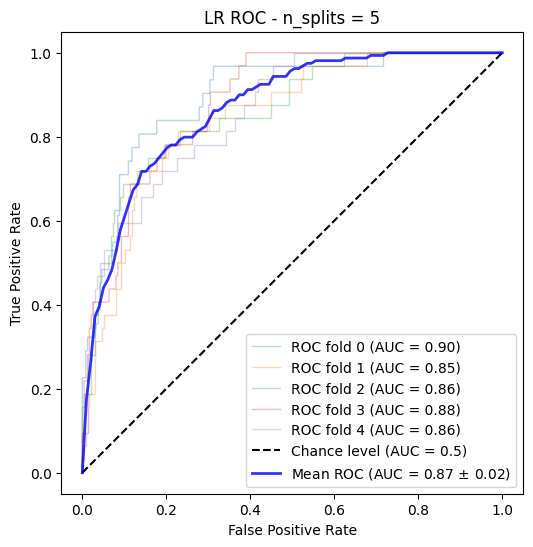


Generating plots for 7 n_splits...



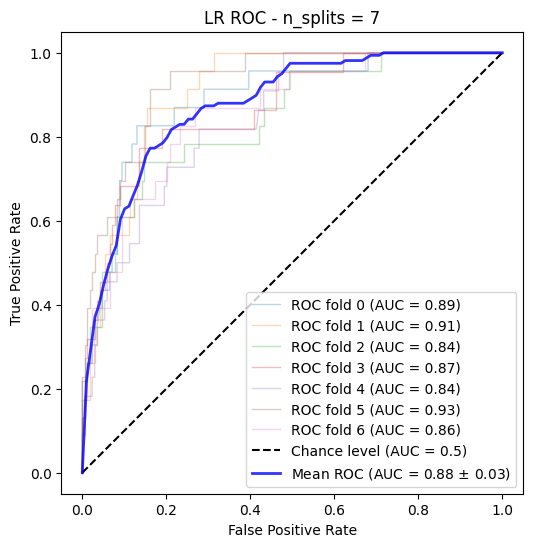


Generating plots for 9 n_splits...



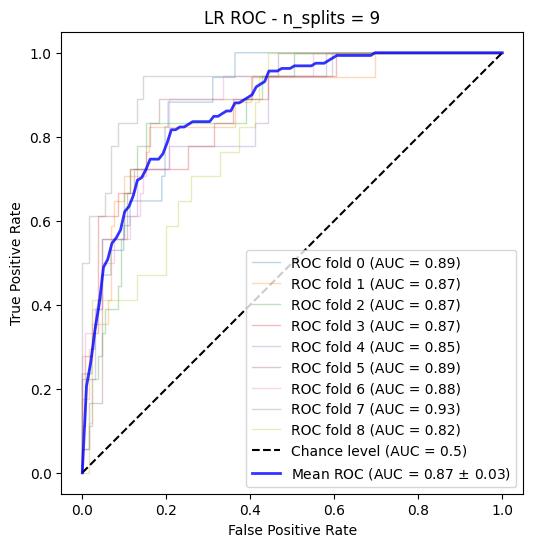

In [66]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(lr, X_train, y_train, i, title=f"LR ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    lr_score_list.append(mean_score)
del lr_score_list

### CV with Random Forest Classifier

In [67]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
rf_score_list = []
for i in cvs:
    rf = RandomForestClassifier(n_estimators=200, random_state=42)

    rf_scores = cross_val_score(
        rf,
        X_train,
        y_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'RFC CV ROC-AUC: {rf_scores}')
    print(f'Mean ROC-AUC : {rf_scores.mean()}\n\nRounded ROC-AUC: {round(rf_scores.mean(), 3)}')
    rf_score_list.append(rf_scores.mean())
    print()

max_rf_score = max(rf_score_list)
print(f'>>> Max rf_score = {round(max_rf_score, 3)}')

---- 5 cv n_splits----

RFC CV ROC-AUC: [0.9475296  0.9357786  0.94286282 0.93299788 0.92750265]
Mean ROC-AUC : 0.9373343106145018

Rounded ROC-AUC: 0.937

---- 7 cv n_splits----

RFC CV ROC-AUC: [0.93002315 0.95086185 0.94468742 0.93504572 0.93827327 0.94849896
 0.92947723]
Mean ROC-AUC : 0.9395525142957059

Rounded ROC-AUC: 0.94

---- 9 cv n_splits----

RFC CV ROC-AUC: [0.90040107 0.95409982 0.90945717 0.96967769 0.93871925 0.93808312
 0.94147583 0.95271416 0.89447687]
Mean ROC-AUC : 0.9332338880497839

Rounded ROC-AUC: 0.933

>>> Max rf_score = 0.94



Generating plots for 5 n_splits...



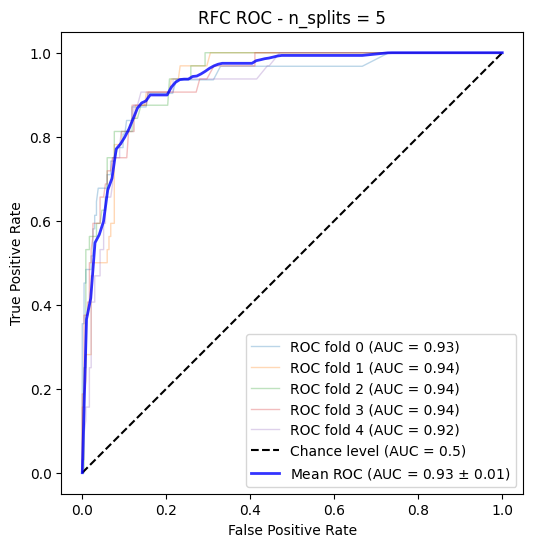


Generating plots for 7 n_splits...



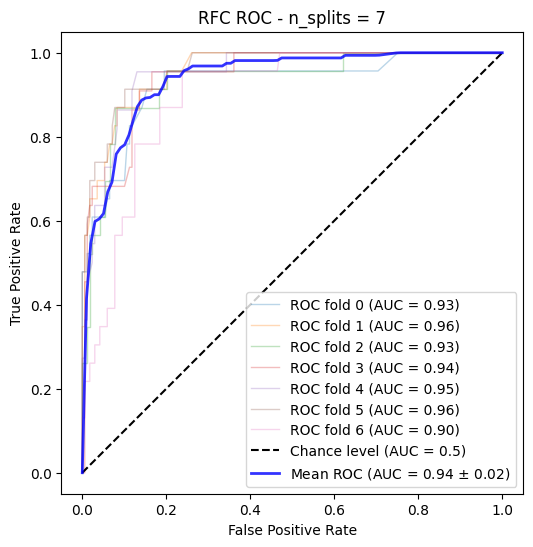


Generating plots for 9 n_splits...



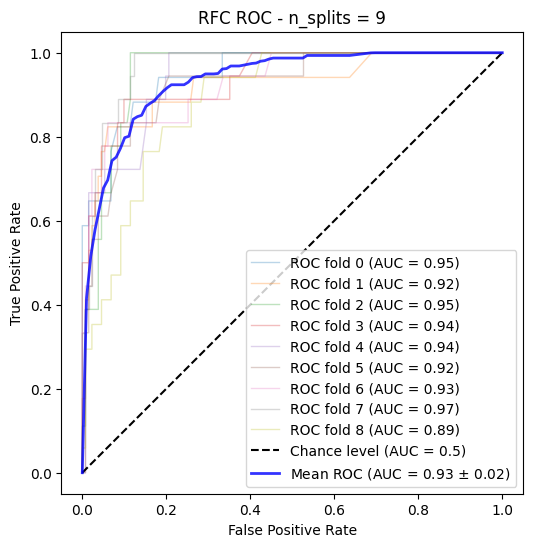

In [69]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(rf, X_train, y_train, i, title=f"RFC ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    rf_score_list.append(mean_score)
del rf_score_list

### CV with Gradient Boosting Classifier

In [70]:
from sklearn.ensemble import GradientBoostingClassifier

In [71]:
gb_score_list = []
for i in cvs:
    gb = GradientBoostingClassifier(random_state=42)
    
    gb_scores = cross_val_score(
        gb,
        X_train,
        y_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'GB CV ROC-AUC: {gb_scores}')
    print(f'Mean ROC-AUC : {gb_scores.mean()}\n\nRounded ROC-AUC: {round(gb_scores.mean(), 3)}')
    gb_score_list.append(gb_scores.mean())
    print()

max_gb_score = max(gb_score_list)
print(f'>>> Max gb_score = {round(max_gb_score, 3)}')

---- 5 cv n_splits----

GB CV ROC-AUC: [0.9508643  0.94637182 0.96305614 0.95762712 0.92412606]
Mean ROC-AUC : 0.9484090884841733

Rounded ROC-AUC: 0.948

---- 7 cv n_splits----

GB CV ROC-AUC: [0.92976589 0.95420633 0.96423977 0.95239376 0.95373857 0.92650104
 0.93322981]
Mean ROC-AUC : 0.9448678809643931

Rounded ROC-AUC: 0.945

---- 9 cv n_splits----

GB CV ROC-AUC: [0.91354724 0.97682709 0.92154368 0.96819338 0.95886344 0.95292621
 0.95928753 0.9461408  0.93803323]
Mean ROC-AUC : 0.9483736229732338

Rounded ROC-AUC: 0.948

>>> Max gb_score = 0.948



Generating plots for 5 n_splits...



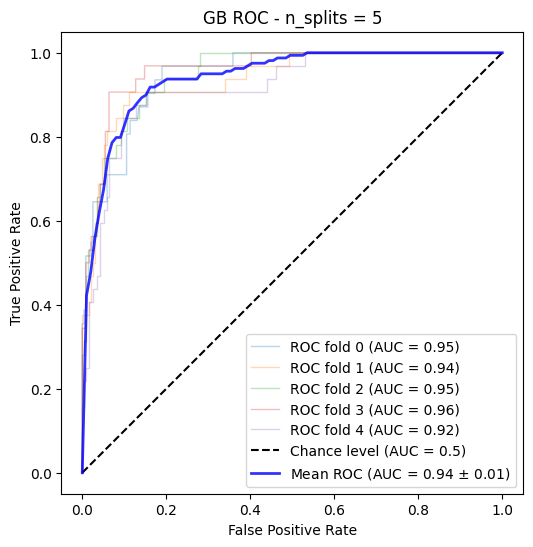


Generating plots for 7 n_splits...



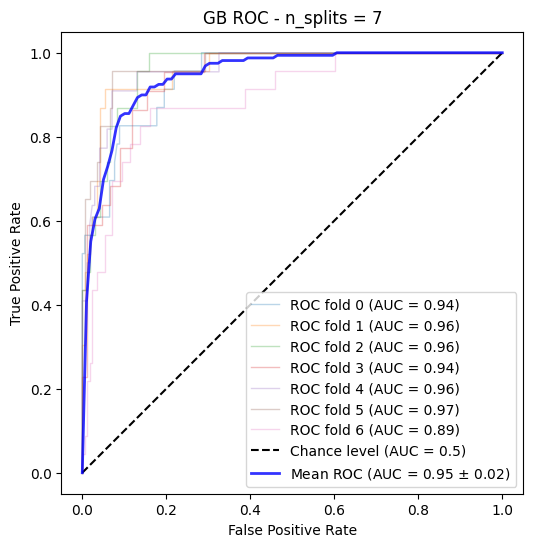


Generating plots for 9 n_splits...



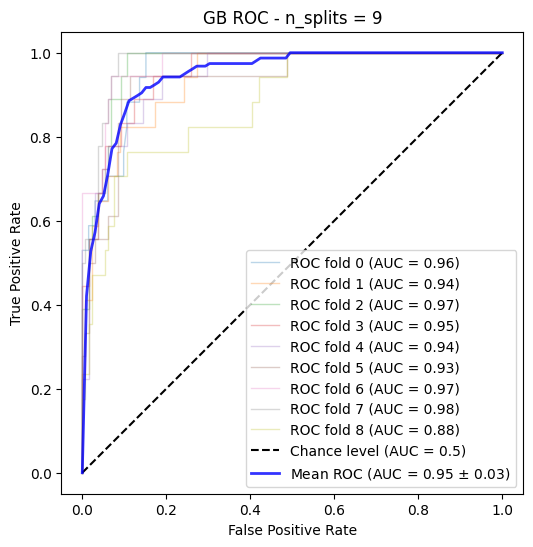

In [72]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(gb, X_train, y_train, i, title=f"GB ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    gb_score_list.append(mean_score)
del gb_score_list

### CV with XGBoost 

In [73]:
from xgboost import XGBClassifier

In [74]:
xgb_score_list = []
for i in cvs:
    xgb = XGBClassifier(n_estimators=200, random_state=42)
    
    xgb_scores = cross_val_score(
        xgb,
        X_train,
        y_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'XGB CV ROC-AUC: {xgb_scores}')
    print(f'Mean ROC-AUC : {xgb_scores.mean()}\n\nRounded ROC-AUC: {round(xgb_scores.mean(), 3)}')
    xgb_score_list.append(xgb_scores.mean())
    print()

max_xgb_score = max(xgb_score_list)
print(f'>>> Max xgb_score = {round(max_xgb_score, 3)}')

---- 5 cv n_splits----

XGB CV ROC-AUC: [0.95399483 0.94769597 0.9592161  0.94743114 0.94067797]
Mean ROC-AUC : 0.9498032028523115

Rounded ROC-AUC: 0.95

---- 7 cv n_splits----

XGB CV ROC-AUC: [0.94623103 0.9480319  0.96192436 0.95750403 0.95669715 0.91666667
 0.94384058]
Mean ROC-AUC : 0.9472708172540949

Rounded ROC-AUC: 0.947

---- 9 cv n_splits----

XGB CV ROC-AUC: [0.9144385  0.97459893 0.93384224 0.98176421 0.95377439 0.95589483
 0.92748092 0.96183206 0.9402784 ]
Mean ROC-AUC : 0.9493227187808837

Rounded ROC-AUC: 0.949

>>> Max xgb_score = 0.95



Generating plots for 5 n_splits...



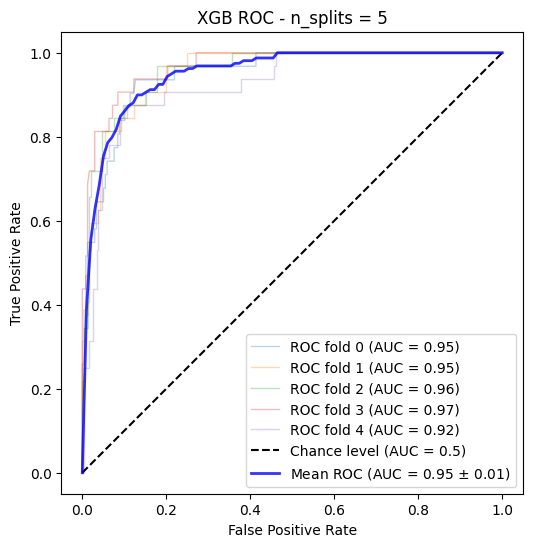


Generating plots for 7 n_splits...



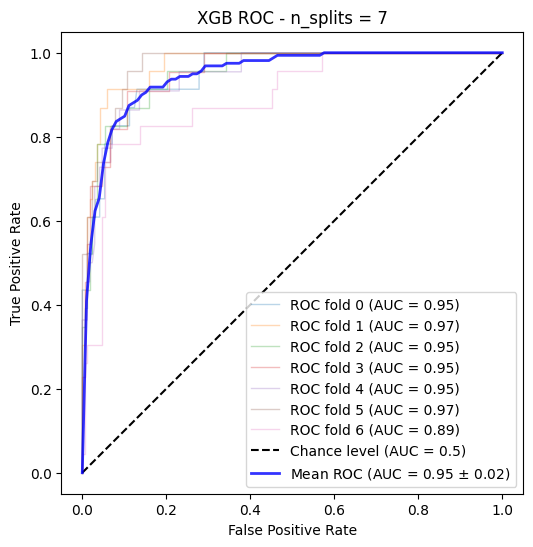


Generating plots for 9 n_splits...



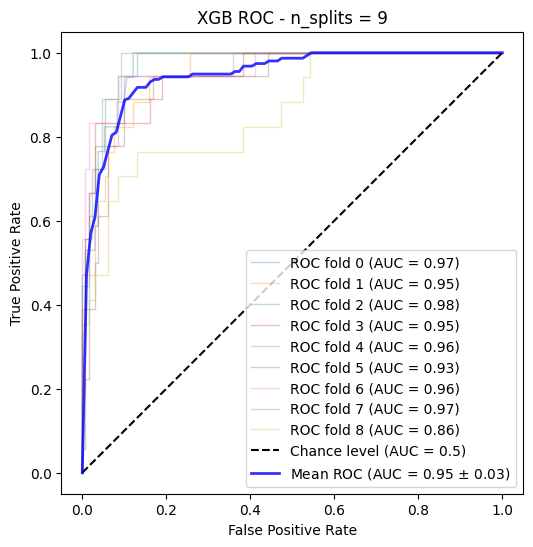

In [75]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(xgb, X_train, y_train, i, title=f"XGB ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    xgb_score_list.append(mean_score)
del xgb_score_list

In [76]:
# <model>  : <ROC-AUC value>
LR_Score = round(max_lr_score.mean(), 3)
RF_Score = round(max_rf_score.mean(), 3)
GB_Score = round(max_gb_score.mean(), 3)
XGB_Score = round(max_xgb_score.mean(), 3)

In [77]:
Scores = {'Logistic Regression': LR_Score, 'Random Forest Classifier': RF_Score, 'Gradient Boosting Classifier': GB_Score, 'XGBoost': XGB_Score}
models = {'Logistic Regression': lr, 'Random Forest Classifier': rf, 'Gradient Boosting Classifier': gb, 'XGBoost': xgb}

best_model_name = max(Scores, key=Scores.get)
best_model = models[best_model_name]

print(f'The Best Model for Training is {best_model_name}')

The Best Model for Training is XGBoost


## Training Model

In [78]:
best_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [79]:
from sklearn.metrics import roc_auc_score

In [80]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]
print(f'Test set ROC-AUC: {round(roc_auc_score(y_test, y_test_proba), 3)}')

Test set ROC-AUC: 0.92


#### Probability Class Splitting

In [81]:
def risk_pred(p):
    if (p < 0.25):
        return 'most likely to stay'
    elif (p >= 0.25 and p < 0.50):
        return 'likely to stay'
    elif (p >= 0.50 and p < 0.75):
        return 'likely to leave'
    else:
        return 'most likely to leave'

In [82]:
# dataset with EmployeeID
EmployeeID_dataset = pd.concat([EmployeeID_safe, X_test], axis=1)
del EmployeeID_safe
display(EmployeeID_dataset.shape)
EmployeeID_dataset.head()

(336, 35)

,EmployeeID,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male,is_other_JobRole
1260,1628396,42,1.0,855,12,3,2,2,57,3,...,5,3,0,4,0.0,1.0,0.0,0.0,1.0,0
709,1658398,29,1.0,906,10,3,1,4,92,2,...,0,0,0,0,0.0,1.0,0.0,1.0,0.0,1
261,1520532,38,0.0,1327,2,2,1,4,39,2,...,8,7,7,5,1.0,0.0,0.0,0.0,1.0,0
107,1410589,25,1.0,240,5,3,3,3,46,2,...,6,4,0,3,1.0,0.0,0.0,0.0,1.0,0
1639,1309082,29,1.0,352,6,1,2,4,87,2,...,1,0,0,0,0.0,0.0,1.0,0.0,1.0,1


In [83]:
# turning prpobability to binary
y_pred_binary = (y_test_proba >= 0.5).astype(int)

In [84]:
results = pd.DataFrame({
    'PersonID': EmployeeID_dataset['EmployeeID'],   
    'Attrition_Probability': y_test_proba,
    'Binary_Prediction': y_pred_binary,
    'Predicted_Risk': [risk_pred(p) for p in y_test_proba],
    'Actual_Attrition': y_test.values
})

In [85]:
results.sample(10)

,PersonID,Attrition_Probability,Binary_Prediction,Predicted_Risk,Actual_Attrition
1529,1563219,1.650987e-05,0,most likely to stay,0
529,1533978,4.222544e-06,0,most likely to stay,0
828,1131723,6.599885e-04,0,most likely to stay,0
1164,1107055,5.271876e-01,1,likely to leave,1
1500,1870096,1.990310e-06,0,most likely to stay,0
321,1625490,7.126512e-07,0,most likely to stay,0
257,1804073,1.117225e-06,0,most likely to stay,0
1485,1540491,7.871796e-07,0,most likely to stay,0
237,1693414,3.634460e-02,0,most likely to stay,0
117,1427732,2.394399e-06,0,most likely to stay,0


In [86]:
from sklearn.metrics import accuracy_score

In [87]:
accuracy = accuracy_score(y_test, y_pred_binary)
print(f'Accuracy: {round(accuracy, 3)}')

Accuracy: 0.914


### Model Evaluation

In [88]:
from sklearn.metrics import classification_report, confusion_matrix

In [89]:
print(f'\n=== {best_model_name} Evaluation ===\n')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_binary))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_binary))


=== XGBoost Evaluation ===

Confusion Matrix:
[[288   8]
 [ 21  19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       296
           1       0.70      0.47      0.57        40

    accuracy                           0.91       336
   macro avg       0.82      0.72      0.76       336
weighted avg       0.90      0.91      0.91       336



## Avoiding Overfitting With Undersampling

In [90]:
from imblearn.under_sampling import RandomUnderSampler

In [91]:
rus = RandomUnderSampler(random_state=42)

In [92]:
# fitting the train set to the under sampler
X_res_train, y_res_train = rus.fit_resample(X_train, y_train)

## Cross Validation for Resampled data

In [93]:
del best_model # save memory

### Resampled CV Logistic Regression

In [94]:
lr_score_list = []
for i in cvs:
    lr = LogisticRegression(max_iter=500, random_state=42)
    
    lr_scores = cross_val_score(
        lr,
        X_res_train,
        y_res_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'LR CV ROC-AUC: {lr_scores}')
    print(f'Mean ROC-AUC : {lr_scores.mean()}\n\nRounded ROC-AUC: {round(lr_scores.mean(), 3)}')
    lr_score_list.append(lr_scores.mean())
    print()

max_lr_score = max(lr_score_list)
print(f'>>> Max lr_score = {round(max_lr_score, 3)}')

---- 5 cv n_splits----

LR CV ROC-AUC: [0.86035156 0.93359375 0.80078125 0.84778226 0.86189516]
Mean ROC-AUC : 0.8608807963709676

Rounded ROC-AUC: 0.861

---- 7 cv n_splits----

LR CV ROC-AUC: [0.79773157 0.92249527 0.91871456 0.78063241 0.88735178 0.8715415
 0.84189723]
Mean ROC-AUC : 0.8600520462524244

Rounded ROC-AUC: 0.86

---- 9 cv n_splits----

LR CV ROC-AUC: [0.82716049 0.92592593 0.90432099 0.89215686 0.77777778 0.98366013
 0.84313725 0.8627451  0.85294118]
Mean ROC-AUC : 0.8744250786734447

Rounded ROC-AUC: 0.874

>>> Max lr_score = 0.874



Generating plots for 5 n_splits...



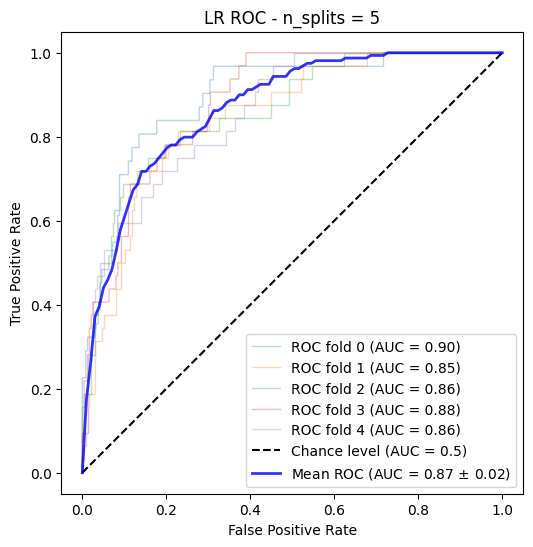


Generating plots for 7 n_splits...



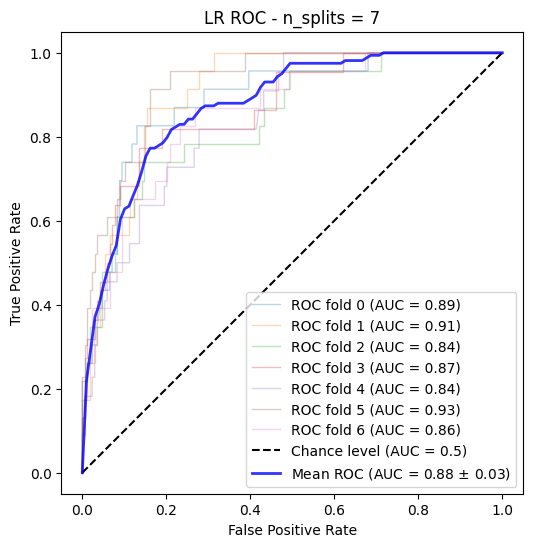


Generating plots for 9 n_splits...



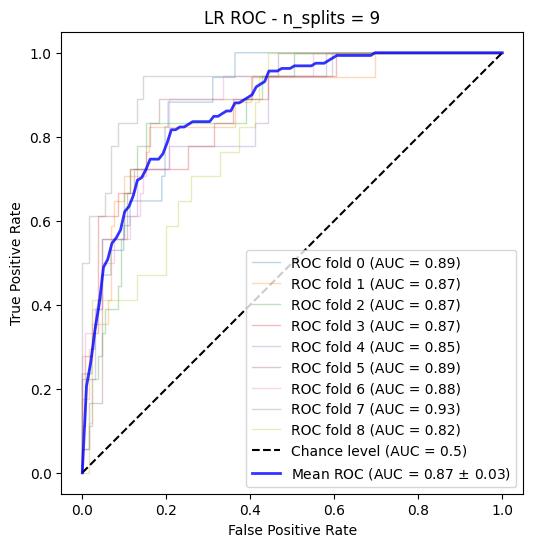

In [95]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(lr, X_train, y_train, i, title=f"LR ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    lr_score_list.append(mean_score)
del lr_score_list

### Resampled CV Random Forest Classifier

In [96]:
rf_score_list = []
for i in cvs:
    rf = RandomForestClassifier(n_estimators=200, random_state=42)

    rf_scores = cross_val_score(
        rf,
        X_res_train,
        y_res_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'RFC CV ROC-AUC: {rf_scores}')
    print(f'Mean ROC-AUC : {rf_scores.mean()}\n\nRounded ROC-AUC: {round(rf_scores.mean(), 3)}')
    rf_score_list.append(rf_scores.mean())
    print()

max_rf_score = max(rf_score_list)
print(f'>>> Max rf_score = {round(max_rf_score, 3)}')

---- 5 cv n_splits----

RFC CV ROC-AUC: [0.92333984 0.93945312 0.94580078 0.89516129 0.94808468]
Mean ROC-AUC : 0.930367943548387

Rounded ROC-AUC: 0.93

---- 7 cv n_splits----

RFC CV ROC-AUC: [0.93383743 0.95274102 0.93478261 0.95454545 0.90118577 0.84881423
 0.92687747]
Mean ROC-AUC : 0.9218262833574743

Rounded ROC-AUC: 0.922

---- 9 cv n_splits----

RFC CV ROC-AUC: [0.91049383 0.96296296 0.93518519 0.94607843 0.92973856 0.96732026
 0.84640523 0.92647059 0.92320261]
Mean ROC-AUC : 0.9275397401759058

Rounded ROC-AUC: 0.928

>>> Max rf_score = 0.93



Generating plots for 5 n_splits...



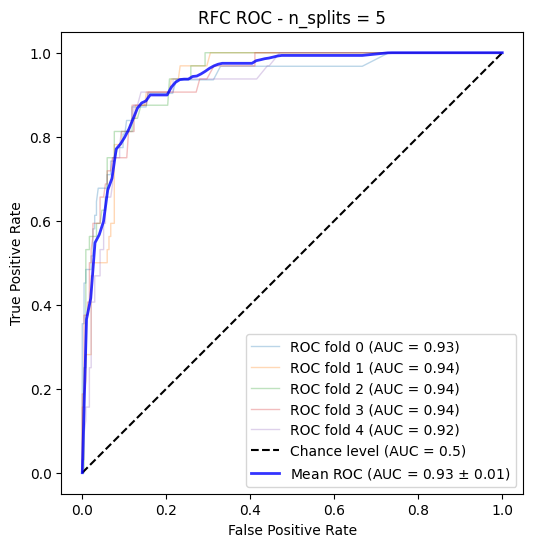


Generating plots for 7 n_splits...



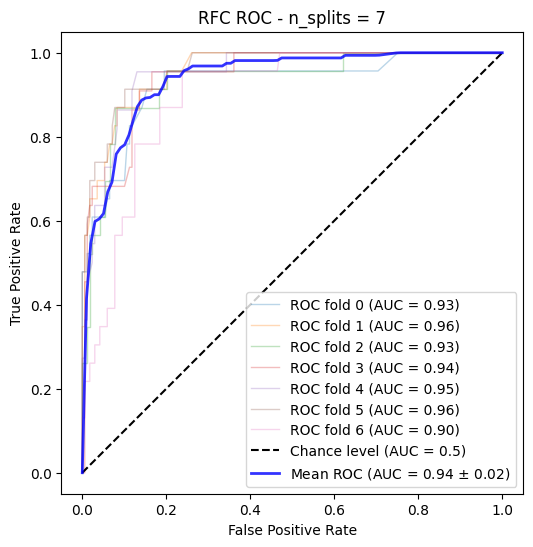


Generating plots for 9 n_splits...



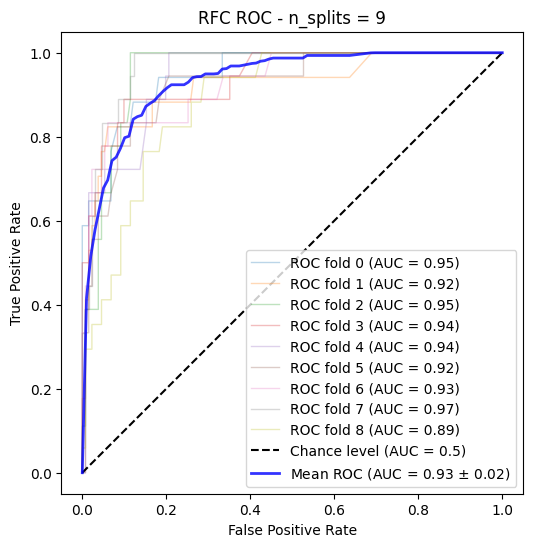

In [97]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(rf, X_train, y_train, i, title=f"RFC ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    rf_score_list.append(mean_score)
del rf_score_list

### Resampled CV Gradient Boosting Classifier

In [98]:
gb_score_list = []
for i in cvs:
    gb = GradientBoostingClassifier(random_state=42)
    
    gb_scores = cross_val_score(
        gb,
        X_res_train,
        y_res_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'GB CV ROC-AUC: {gb_scores}')
    print(f'Mean ROC-AUC : {gb_scores.mean()}\n\nRounded ROC-AUC: {round(gb_scores.mean(), 3)}')
    gb_score_list.append(gb_scores.mean())
    print()

max_gb_score = max(gb_score_list)
print(f'>>> Max gb_score = {round(max_gb_score, 3)}')

---- 5 cv n_splits----

GB CV ROC-AUC: [0.9140625  0.93945312 0.9375     0.88104839 0.94354839]
Mean ROC-AUC : 0.9231224798387097

Rounded ROC-AUC: 0.923

---- 7 cv n_splits----

GB CV ROC-AUC: [0.89224953 0.97920605 0.91115312 0.9229249  0.93280632 0.83003953
 0.93083004]
Mean ROC-AUC : 0.9141727837380011

Rounded ROC-AUC: 0.914

---- 9 cv n_splits----

GB CV ROC-AUC: [0.89506173 0.98148148 0.94444444 0.92810458 0.89542484 0.94444444
 0.86601307 0.87254902 0.92810458]
Mean ROC-AUC : 0.9172920196885338

Rounded ROC-AUC: 0.917

>>> Max gb_score = 0.923



Generating plots for 5 n_splits...



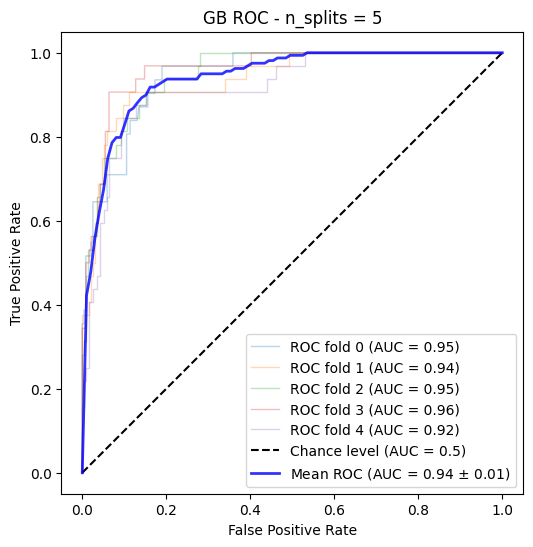


Generating plots for 7 n_splits...



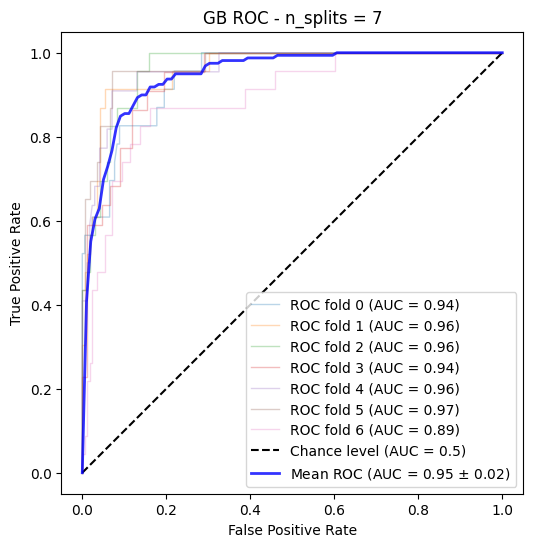


Generating plots for 9 n_splits...



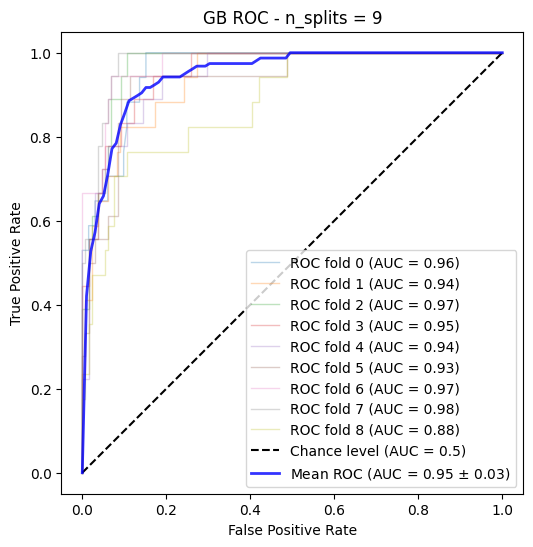

In [99]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(gb, X_train, y_train, i, title=f"GB ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    gb_score_list.append(mean_score)
del gb_score_list

### Resampled CV XGBoost

In [100]:
xgb_score_list = []
for i in cvs:
    xgb = XGBClassifier(
        n_estimators=200,        # not too large
        learning_rate=0.05,      # LOWER than default
        max_depth=3,             # very important (reduce)
        min_child_weight=5,      # prevents small leaf splits
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,           # L1 regularization
        reg_lambda=1.0,          # L2 regularization
        eval_metric="logloss",
        random_state=42
    )
    
    xgb_scores = cross_val_score(
        xgb,
        X_res_train,
        y_res_train,
        cv=i,
        scoring='roc_auc'
    )
    
    print(f'---- {5 + ((cvs.index(i) + 1) - 1)*2} cv n_splits----\n')
    print(f'XGB CV ROC-AUC: {xgb_scores}')
    print(f'Mean ROC-AUC : {xgb_scores.mean()}\n\nRounded ROC-AUC: {round(xgb_scores.mean(), 3)}')
    xgb_score_list.append(xgb_scores.mean())
    print()

max_xgb_score = max(xgb_score_list)
print(f'>>> Max xgb_score = {round(max_xgb_score, 3)}')

---- 5 cv n_splits----

XGB CV ROC-AUC: [0.96289062 0.95507812 0.95019531 0.88810484 0.96270161]
Mean ROC-AUC : 0.9437941028225806

Rounded ROC-AUC: 0.944

---- 7 cv n_splits----

XGB CV ROC-AUC: [0.93950851 0.96786389 0.9489603  0.93873518 0.95849802 0.85968379
 0.97628458]
Mean ROC-AUC : 0.941362040605897

Rounded ROC-AUC: 0.941

---- 9 cv n_splits----

XGB CV ROC-AUC: [0.9382716  0.97530864 0.9537037  0.94117647 0.92810458 0.97385621
 0.86928105 0.90849673 0.96732026]
Mean ROC-AUC : 0.9395021383038813

Rounded ROC-AUC: 0.94

>>> Max xgb_score = 0.944



Generating plots for 5 n_splits...



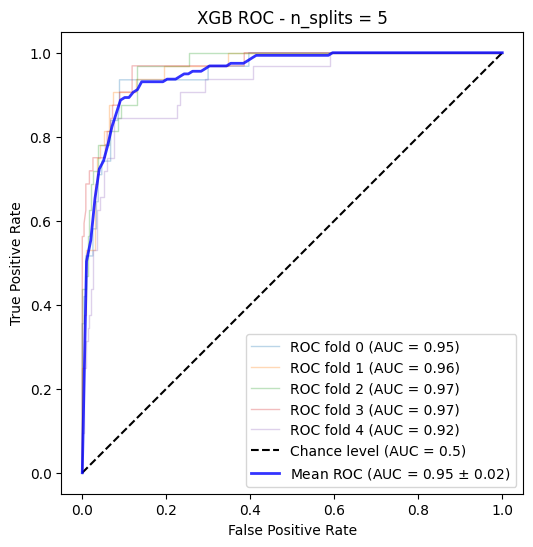


Generating plots for 7 n_splits...



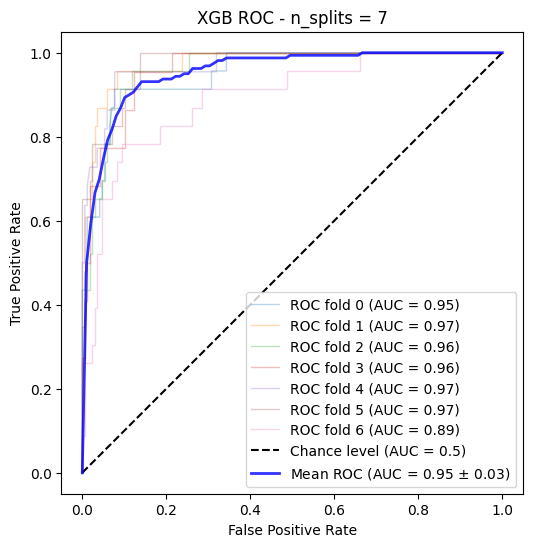


Generating plots for 9 n_splits...



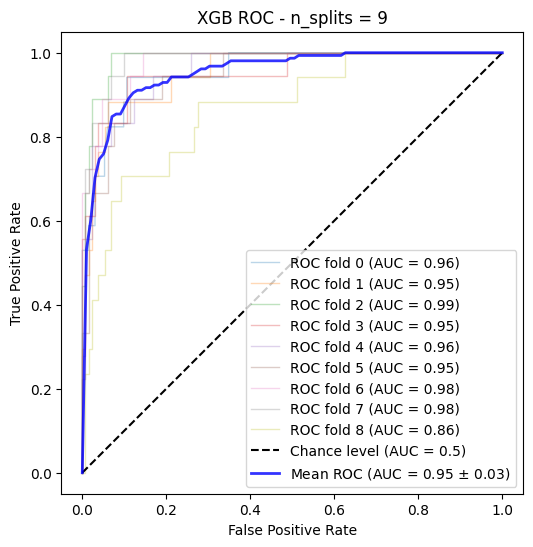

In [101]:
for i in cvs:
    print(f"\nGenerating plots for {5 + ((cvs.index(i) + 1) - 1)*2} n_splits...\n")
    mean_score = plot_custom_roc_cv(xgb, X_train, y_train, i, title=f"XGB ROC - n_splits = {5 + ((cvs.index(i) + 1) - 1)*2}")
    xgb_score_list.append(mean_score)
del xgb_score_list

In [102]:
LR_Score = round(max_lr_score.mean(), 3)
RF_Score = round(max_rf_score.mean(), 3)
GB_Score = round(max_gb_score.mean(), 3)
XGB_Score = round(max_xgb_score.mean(), 3)

In [103]:
Scores = {'Logistic Regression': LR_Score, 'Random Forest Classifier': RF_Score, 'Gradient Boosting Classifier': GB_Score, 'XGBoost': XGB_Score}
models = {'Logistic Regression': lr, 'Random Forest Classifier': rf, 'Gradient Boosting Classifier': gb, 'XGBoost': xgb}

best_model_name = max(Scores, key=Scores.get)
best_resampled_model = models[best_model_name]

print(f'The Best Model for Training is {best_model_name}')

The Best Model for Training is XGBoost


In [104]:
best_resampled_model.fit(X_res_train, y_res_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [105]:
y_test_proba = best_resampled_model.predict_proba(X_test)[:, 1]
print(f'Test set ROC-AUC: {round(roc_auc_score(y_test, y_test_proba), 3)}')

Test set ROC-AUC: 0.928


In [106]:
results.sample(10)

,PersonID,Attrition_Probability,Binary_Prediction,Predicted_Risk,Actual_Attrition
553,1639147,1.597443e-05,0,most likely to stay,0
1,1200302,1.039731e-06,0,most likely to stay,0
262,1593179,4.614895e-04,0,most likely to stay,0
446,1372229,5.002012e-05,0,most likely to stay,0
476,1079394,3.065626e-05,0,most likely to stay,0
1285,1083173,2.003347e-07,0,most likely to stay,0
1096,1044155,1.821157e-04,0,most likely to stay,0
1471,1548714,1.556851e-07,0,most likely to stay,0
956,1510065,6.843482e-06,0,most likely to stay,0
1345,1551391,3.935382e-04,0,most likely to stay,0


In [107]:
y_pred_binary = (y_test_proba >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred_binary)

print(f'Accuracy: {round(accuracy, 3)}')

Accuracy: 0.881


In [108]:
print(f'\n=== {best_model_name} Evaluation with Resampled Train-Set ===\n')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_binary))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_binary))


=== XGBoost Evaluation with Resampled Train-Set ===

Confusion Matrix:
[[262  34]
 [  6  34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       296
           1       0.50      0.85      0.63        40

    accuracy                           0.88       336
   macro avg       0.74      0.87      0.78       336
weighted avg       0.92      0.88      0.89       336



In [109]:
# Train (RESAMPLED)
y_train_res_proba = best_resampled_model.predict_proba(X_res_train)[:, 1]
train_auc = roc_auc_score(y_res_train, y_train_res_proba)

# Test (ORIGINAL, untouched)
y_test_proba = best_resampled_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Train ROC-AUC (resampled):", round(train_auc, 3))
print("Test ROC-AUC:", round(test_auc, 3))

Train ROC-AUC (resampled): 0.991
Test ROC-AUC: 0.928


## Using scale_pos_weight (No RandomUnderSampler)

In [110]:
pos_sum = (y_train == 1).sum()
neg_sum = (y_train == 0).sum()
display(pos_sum)
display(neg_sum)

np.int64(159)

np.int64(1181)

In [111]:
proportion = neg_sum / pos_sum
display(proportion)

np.float64(7.427672955974843)

In [112]:
xgb = XGBClassifier(
    n_estimators=200,        
    eta=0.05,      
    max_depth=3,             
    min_child_weight=5, 
    gamma=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,           
    reg_lambda=1.0,          
    eval_metric="logloss",
    random_state=42,
    n_jobs=3,
    scale_pos_weight=proportion,
    verbose=1
)

xgb_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=7,
    scoring='roc_auc'
)

print(f'GB CV ROC-AUC: {gb_scores}')
print(f'Mean ROC-AUC : {gb_scores.mean()}\n\nRounded ROC-AUC: {round(gb_scores.mean(), 3)} ')

GB CV ROC-AUC: [0.89506173 0.98148148 0.94444444 0.92810458 0.89542484 0.94444444
 0.86601307 0.87254902 0.92810458]
Mean ROC-AUC : 0.9172920196885338

Rounded ROC-AUC: 0.917 


In [113]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [114]:
y_test_proba = xgb.predict_proba(X_test)[:, 1]
print(f'Test set ROC-AUC: {round(roc_auc_score(y_test, y_test_proba), 3)}')

Test set ROC-AUC: 0.917


In [115]:
y_pred_binary = (y_test_proba >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred_binary)

print(f'Accuracy: {round(accuracy, 3)}')

Accuracy: 0.896


In [116]:
print(f'\n=== {best_model_name} Evaluation with Resampled Train-Set ===\n')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_binary))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_binary))


=== XGBoost Evaluation with Resampled Train-Set ===

Confusion Matrix:
[[275  21]
 [ 14  26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       296
           1       0.55      0.65      0.60        40

    accuracy                           0.90       336
   macro avg       0.75      0.79      0.77       336
weighted avg       0.90      0.90      0.90       336



In [117]:
y_train_proba = xgb.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, y_train_proba)

y_test_proba = xgb.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Train ROC-AUC :", round(train_auc, 3))
print("Test ROC-AUC  :", round(test_auc, 3))

Train ROC-AUC : 0.997
Test ROC-AUC  : 0.917


## Probability Threshold For Best Precision and Recall

In [119]:
max_precision_proba, max_recall_proba = proba_divider_threshold(y_test, y_test_proba)

Probability With Max Precision: 0.73
Probability With Max Recall: 0.25


In [120]:
y_pred_binary = (y_test_proba >= max_precision_proba).astype(int)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_binary))


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       296
           1       0.79      0.55      0.65        40

    accuracy                           0.93       336
   macro avg       0.86      0.76      0.80       336
weighted avg       0.92      0.93      0.92       336



## Probability Threshold For Best Precision and Recall 

In [121]:
y_pred_binary = (y_test_proba >= max_recall_proba).astype(int)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_binary))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       296
           1       0.43      0.80      0.56        40

    accuracy                           0.85       336
   macro avg       0.70      0.83      0.74       336
weighted avg       0.91      0.85      0.87       336



In [ ]:
# get all three mean ROC-AUC curves in one plot in each model